<a href="https://colab.research.google.com/github/RGarancs/applied-ai-academy-labs/blob/main/solutions/pricingpromo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pricing & promotion — marketing case study

**Applied AI Academy — problem set with worked answers**

**Rows:** 2,200  ·  **Source file:** `pricing_promo.csv`



---
### How to use this notebook
Run the cells in order. Each problem is stated first, then solved, then the
answer is spelled out. For teaching, hide the solution cells and let the room
attempt the task before revealing them.

> The data loads straight from `appliedai.center` — nothing to upload.


## Setup

In [1]:
%matplotlib inline
import pandas as pd, numpy as np, os, urllib.request
import matplotlib, matplotlib.pyplot as plt
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

# Applied AI Academy chart style — calm, legible when projected
INK, ACCENT, CORE, BUILDER, DANGER = "#26214a", "#544d94", "#5b8a6e", "#a8845c", "#b05a5a"
matplotlib.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c9c4d8", "axes.labelcolor": INK, "axes.titlesize": 13,
    "axes.titleweight": "600", "axes.titlecolor": INK, "axes.titlepad": 14,
    "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "font.size": 10, "grid.color": "#e6e2ef", "axes.grid": True,
    "axes.axisbelow": True, "grid.linewidth": .8, "figure.facecolor": "white",
})

URL   = "https://appliedai.center/assets/datasets/pricing_promo.csv"
LOCAL = "pricing_promo.csv"
if not os.path.exists(LOCAL):
    print("Downloading", URL)
    urllib.request.urlretrieve(URL, LOCAL)

df = pd.read_csv(LOCAL, low_memory=False)
print("Shape:", df.shape)
df.head()

Shape: (2200, 16)


,week_id,store,sku,product,category,shelf_position,regular_price_eur,net_price_eur,discount_pct,competitor_price_eur,display_flag,promo_type,units_sold,revenue_eur,gross_margin_pct,stockout_flag
0,2026-W01,Berlin Flagship,SKU2001,protein bar,Grocery,eye_level,4.2,3.31,0.20,4.60,False,price_cut,209,691.79,0.328,False
1,2026-W02,Helsinki Local,SKU2002,laundry gel,Household,eye_level,4.2,2.96,0.35,3.74,False,loyalty_coupon,285,843.60,0.328,False
2,2026-W03,Riga Central,SKU2005,toothpaste,Health,top,9.5,9.27,0.00,8.47,False,none,100,927.00,0.403,True
3,2026-W04,Vilnius North,SKU2007,wireless mouse,Electronics,endcap,29.9,30.58,0.00,35.67,False,none,207,6330.06,0.411,False
4,2026-W05,Helsinki Local,SKU2003,sparkling water,Grocery,eye_level,4.2,3.46,0.20,3.85,False,multibuy,138,477.48,0.338,False


## What is in the file

In [2]:
print("Columns and types:")
print(df.dtypes.to_string())
miss = df.isna().sum()
miss = miss[miss > 0]
print("\nMissing values:" if len(miss) else "\nNo missing values.")
if len(miss): print(miss.to_string())

Columns and types:
week_id                     str
store                       str
sku                         str
product                     str
category                    str
shelf_position              str
regular_price_eur       float64
net_price_eur           float64
discount_pct            float64
competitor_price_eur    float64
display_flag               bool
promo_type                  str
units_sold                int64
revenue_eur             float64
gross_margin_pct        float64
stockout_flag              bool

No missing values.


---
## Problem 1 · Easy — describe

Do displayed items sell more than non-displayed? Does eye-level shelf position sell more than bottom? By how much? (Describe — do not conclude cause yet.)

*Try it yourself first. The worked solution is below.*

In [3]:
print(f"Rows: {len(df):,}  Stores: {df['store'].nunique()}  SKUs: {df['sku'].nunique()}")
print(f"Total revenue: EUR {df['revenue_eur'].sum():,.0f}")
print("\nBy promo type:")
print(df.groupby("promo_type").agg(weeks=("units_sold","size"), units=("units_sold","sum"),
                                   revenue=("revenue_eur","sum"),
                                   margin=("gross_margin_pct","mean")).round(1))

Rows: 2,200  Stores: 6  SKUs: 10
Total revenue: EUR 2,497,535

By promo type:
                weeks   units    revenue  margin
promo_type                                      
bundle            281   56922   345033.9     0.4
loyalty_coupon    280   54832   355674.9     0.4
multibuy          253   51421   336509.0     0.4
none             1100  140730  1074562.1     0.4
price_cut         286   56588   385755.0     0.4


---
## Problem 2 · Intermediate — build

Estimate price elasticity: how do units respond to discount_pct? Separate the discount effect from the display effect with a grouped comparison. Which promo_type gives the best lift per € of margin sacrificed?

*Try it yourself first. The worked solution is below.*

In [4]:
d = df[(df.regular_price_eur>0) & (df.net_price_eur>0) & (df.units_sold>0)].copy()
import numpy as np
d["ln_p"], d["ln_q"] = np.log(d["net_price_eur"]), np.log(d["units_sold"])
el = np.polyfit(d["ln_p"], d["ln_q"], 1)[0]
print(f"Overall price elasticity: {el:.2f}")
print("(-1 means a 1% price cut buys a 1% volume rise; below -1 = elastic)")
print("\nElasticity by category:")
for c, g in d.groupby("category"):
    if len(g) > 60:
        print(f"  {c:<18} {np.polyfit(g['ln_p'], g['ln_q'], 1)[0]:+.2f}   (n={len(g)})")

Overall price elasticity: -0.10
(-1 means a 1% price cut buys a 1% volume rise; below -1 = elastic)

Elasticity by category:
  Electronics        -1.67   (n=209)
  Grocery            -1.85   (n=1093)
  Health             -1.84   (n=427)
  Household          -1.74   (n=236)
  Stationery         -1.85   (n=235)


---
## Problem 3 · Advanced — judge

Argue the causation trap: displayed/discounted items may already be popular. Design an experiment (which SKUs, which stores, how long) that would ISOLATE the true promo effect — the thing this observational data cannot prove.

*Try it yourself first. The worked solution is below.*

In [5]:
promo = df[df.discount_pct > 0]; base = df[df.discount_pct == 0]
print(f"Promo weeks:    units {promo.units_sold.mean():.1f}  margin {promo.gross_margin_pct.mean():.1f}%")
print(f"Non-promo weeks: units {base.units_sold.mean():.1f}  margin {base.gross_margin_pct.mean():.1f}%")

band = pd.cut(df["discount_pct"], [-.001,0,.1,.2,.3,1],
              labels=["none","1-10%","11-20%","21-30%","30%+"])
t = (df.groupby(band, observed=True)
       .agg(weeks=("units_sold","size"), units=("units_sold","mean"),
            revenue=("revenue_eur","mean"), margin=("gross_margin_pct","mean")).round(1))
print("\n", t)
print("\nDeep discounts move units and destroy margin. The question a pricing")
print("team must answer is whether the volume is INCREMENTAL or just pulled forward.")

Promo weeks:    units 199.8  margin 0.4%
Non-promo weeks: units 127.9  margin 0.4%

               weeks  units  revenue  margin
discount_pct                               
none           1100  127.9    976.9     0.4
1-10%           461  170.8   1268.7     0.4
11-20%          440  207.0   1334.6     0.4
30%+            199  250.9   1260.5     0.3

Deep discounts move units and destroy margin. The question a pricing
team must answer is whether the volume is INCREMENTAL or just pulled forward.


---
## Visual summary

The same answers, as pictures. These are what to project — a room reads a chart
far faster than it reads a table, and the shape of a result is usually the
argument you are actually making.

findfont: Failed to find font weight 600, now using 700.


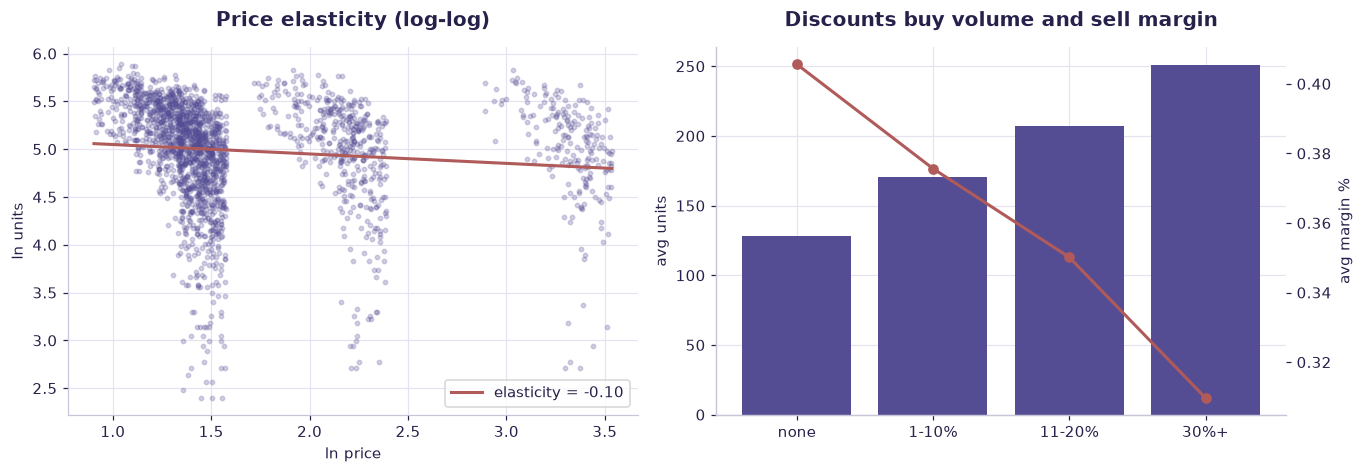

In [6]:
d = df[(df.net_price_eur > 0) & (df.units_sold > 0)].copy()
d["ln_p"], d["ln_q"] = np.log(d.net_price_eur), np.log(d.units_sold)
el = np.polyfit(d.ln_p, d.ln_q, 1)
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.4))
ax[0].scatter(d.ln_p, d.ln_q, s=8, alpha=.25, color=ACCENT)
xs = np.linspace(d.ln_p.min(), d.ln_p.max(), 50)
ax[0].plot(xs, np.polyval(el, xs), color=DANGER, lw=2, label=f"elasticity = {el[0]:.2f}")
ax[0].set_title("Price elasticity (log-log)"); ax[0].set_xlabel("ln price"); ax[0].set_ylabel("ln units"); ax[0].legend()

band = pd.cut(df["discount_pct"], [-.001,0,.1,.2,.3,1], labels=["none","1-10%","11-20%","21-30%","30%+"])
g = df.groupby(band, observed=True).agg(units=("units_sold","mean"), margin=("gross_margin_pct","mean"))
a2 = ax[1]; a3 = a2.twinx(); a3.grid(False)
a2.bar(g.index.astype(str), g["units"], color=ACCENT, label="units")
a3.plot(g.index.astype(str), g["margin"], color=DANGER, marker="o", lw=2, label="margin %")
a2.set_title("Discounts buy volume and sell margin"); a2.set_ylabel("avg units"); a3.set_ylabel("avg margin %")
plt.tight_layout(); plt.show()

---
## Verified answer key

These are the numbers the academy ships for this dataset. They were computed
from this exact file — if your run disagrees, reconcile before teaching it.

1. Displayed items sell ~196 units vs ~152 without — a real but confounded lift
2. The marketing trap: promoted & well-placed items were often already best-sellers (correlation != causation)
3. Elasticity is the intermediate skill; the advanced skill is designing the experiment observational data cannot replace
4. Ties directly to Lesson 11 causality trap and Lesson 12 "growth without eroding trust"


---
## Teaching notes

* **Run the Easy problem live.** It sets the shared vocabulary and gets everyone
  looking at the same rows.
* **Let them fail on the Intermediate one.** The productive mistake is usually
  reaching for a model before checking the data.
* **Argue about the Advanced one.** It has no single right answer; it has a
  defensible one, and defending it is the skill being taught.
* **Always close on limitations.** Every dataset here has a real caveat —
  scrape bias, a tiny sample, a hindsight label. Naming it is the lesson.


---
*Applied AI Academy · appliedai.center*
